## PHASE 1: EXPLORATION AND DATA CLEANING
This section covers loading the data, initial exploration, merging, and handling missing values.

In [688]:
# Essential library imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Suppress technical warnings and file paths in output
warnings.filterwarnings('ignore')

# Global environment configuration
pd.set_option("display.max_columns", None)

### =========================================
### 1. Exploratory Data Analysis (EDA) and Data Cleaning
### =========================================

In [689]:
df_flights = pd.read_csv("Customer Flight Activity.csv") # Load dataset

display(df_flights.head(2)) # Flights dataset exploration
print("=" * 100)

display(df_flights.tail(2))
print("=" * 100)

display(df_flights.sample(2))
print(f"The flights dataframe has {df_flights.shape[0]} rows and {df_flights.shape[1]} columns")

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
405622,999982,2018,12,0,0,0,0,0.0,0,0
405623,999986,2018,12,0,0,0,0,0.0,0,0


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
344742,459404,2018,9,15,7,22,3080,308.0,0,0
119789,180207,2017,8,0,0,0,0,0.0,0,0


The flights dataframe has 405624 rows and 10 columns


In [690]:
df_loyalty = pd.read_csv("Customer Loyalty History.csv")

display(df_loyalty.head(2)) # Loyalty dataset exploration
print("=" * 100)

display(df_loyalty.tail(2))
print("=" * 100)

display(df_loyalty.sample(2))
print(f"The loyalty dataframe has {df_loyalty.shape[0]} rows and {df_loyalty.shape[1]} columns")

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,-57297.0,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN
16736,652627,Canada,Manitoba,Winnipeg,R2C 0M5,Female,Bachelor,75049.0,Married,Star,83325.38,Standard,2015,12,2016.0,8.0


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
13766,616641,Canada,Ontario,Toronto,M2M 7K8,Male,Bachelor,81518.0,Divorced,Star,5548.03,Standard,2018,9,NaN,NaN
8485,925353,Canada,Manitoba,Winnipeg,R2C 0M5,Male,Bachelor,59265.0,Married,Nova,9192.59,Standard,2017,2,NaN,NaN


The loyalty dataframe has 16737 rows and 16 columns


In [691]:
# Detailed information for Flights
print("--- Flights Data Summary Table ---")
flights_summary = pd.DataFrame({
    'Data Type': df_flights.dtypes,
    'Non-Null Count': df_flights.count(),
    'Null Count': df_flights.isnull().sum(),
    'Null Percentage (%)': (df_flights.isnull().sum() / len(df_flights)) * 100
}).round(2)
display(flights_summary)

--- Flights Data Summary Table ---


,Data Type,Non-Null Count,Null Count,Null Percentage (%)
Loyalty Number,int64,405624,0,0.0
Year,int64,405624,0,0.0
Month,int64,405624,0,0.0
Flights Booked,int64,405624,0,0.0
Flights with Companions,int64,405624,0,0.0
Total Flights,int64,405624,0,0.0
Distance,int64,405624,0,0.0
Points Accumulated,float64,405624,0,0.0
Points Redeemed,int64,405624,0,0.0
Dollar Cost Points Redeemed,int64,405624,0,0.0


In [692]:
# Detailed information for Loyalty
print("--- Loyalty Data Summary Table ---")
loyalty_summary = pd.DataFrame({
    'Data Type': df_loyalty.dtypes,
    'Non-Null Count': df_loyalty.count(),
    'Null Count': df_loyalty.isnull().sum(),
    'Null Percentage (%)': (df_loyalty.isnull().sum() / len(df_loyalty)) * 100
}).round(2)
display(loyalty_summary)

--- Loyalty Data Summary Table ---


,Data Type,Non-Null Count,Null Count,Null Percentage (%)
Loyalty Number,int64,16737,0,0.00
Country,object,16737,0,0.00
Province,object,16737,0,0.00
City,object,16737,0,0.00
Postal Code,object,16737,0,0.00
Gender,object,16737,0,0.00
Education,object,16737,0,0.00
Salary,float64,12499,4238,25.32
Marital Status,object,16737,0,0.00
Loyalty Card,object,16737,0,0.00


### Observations & Cleaning Strategy

Based on the exploratory data analysis, the following technical strategies have been defined for data cleaning and merging:
 
### **Flights Dataset:**
 * **Identifiers:** Retain `loyalty_number` as `int64` to optimize memory and join performance. As a unique ID, statistical aggregations (mean, median) are not applicable.
 * **Data Integrity & Valid Zeros:** Although there are no null values, we must verify that `loyalty_number`, `year`, and `month` are strictly > 0 to rule out corrupt records. Zeros in flight metrics (e.g., flights booked) represent valid inactive months for users and must be strictly preserved to avoid distorting the temporal behavior.
 * **Temporal Engineering:** Combine the `year` and `month` integer columns into a unified `datetime` feature (`flight_date`) for proper time-series analysis.
 * **Type Consistency:** Cast `points_redeemed` and `dollar_cost_points_redeemed` to `float` to maintain consistency with the `points_accumulated` format.

### **Loyalty Dataset:**
 * **Relational Key:** `loyalty_number` remains an `int64` and will serve as the primary key for joining both dataframes.
 * **Categorical Audit:** String columns will be audited to verify the absence of pseudo-duplicate categories. 
 * **Missing Data & Anomalies (Salary):**  Approximately 25% of `salary` data is missing. We must first identify and neutralize anomalies (e.g., negative salaries) before applying median imputation to avoid skewing the distribution.
 * **Temporal Engineering:** Combine enrollment and cancellation periods into unified `enrollment_date` and `cancellation_date` columns.
 * **Temporal Features & Cancellations (MNAR Strategy):** Over 87% of cancellation data is null, indicating active memberships (Missing Not At Random). To extract this business value, we will create a boolean `is_active` feature. Then, we will generate a unified `cancellation_date` (leaving active users as `NaT`), and finally, drop the original, redundant cancellation year and month columns to optimize memory.


#### Global Schema Standardization (columns)

In [693]:
def standardize_headers(df): # Converts all column names to snake_case format for consistency
    original_cols = df.columns.tolist()
    df.columns = [col.lower().replace(" ", "_") for col in df.columns]
    print(f"Headers standardized: {len(original_cols)} columns processed.")
    return df

In [694]:
# Apply column standardization to both datasets to ensure a uniform schema
df_flights = standardize_headers(df_flights)
df_loyalty = standardize_headers(df_loyalty)

print("\n--- Standardized Flights Headers ---")
print(df_flights.columns.tolist())

print("\n--- Standardized Loyalty Headers ---")
print(df_loyalty.columns.tolist())

Headers standardized: 10 columns processed.
Headers standardized: 16 columns processed.

--- Standardized Flights Headers ---
['loyalty_number', 'year', 'month', 'flights_booked', 'flights_with_companions', 'total_flights', 'distance', 'points_accumulated', 'points_redeemed', 'dollar_cost_points_redeemed']

--- Standardized Loyalty Headers ---
['loyalty_number', 'country', 'province', 'city', 'postal_code', 'gender', 'education', 'salary', 'marital_status', 'loyalty_card', 'clv', 'enrollment_type', 'enrollment_year', 'enrollment_month', 'cancellation_year', 'cancellation_month']


In [695]:
# Combines separate year and month columns into a single unified datetime object.
def create_datetime_feature(df, year_col, month_col, new_name, position=None): # Specifying the insertion position.
    # Create a temporary DataFrame with standardized names for pd.to_datetime
    temp_df = df[[year_col, month_col]].rename(columns={year_col: 'year', month_col: 'month'})
    # Convert to datetime (NaNs will correctly result in NaT - Not a Time)
    new_series = pd.to_datetime(temp_df.assign(day=1)).dt.to_period('M')  # This removes the 'day' component visually while retaining time-series capabilities
    # Insert at specific position if provided, otherwise append to the end
    if position is not None:
        df.insert(position, new_name, new_series)
    else:
        df[new_name] = new_series

    df.drop(columns=[year_col, month_col], inplace=True) # Drop redundant source columns
    return df

In [696]:
df_flights = create_datetime_feature(df_flights, 'year', 'month', 'flight_date', position=2) # Create flight_date

# Create enrollment_date and cancellation_date
df_loyalty = create_datetime_feature(df_loyalty, 'enrollment_year', 'enrollment_month', 'enrollment_date') 
df_loyalty = create_datetime_feature(df_loyalty, 'cancellation_year', 'cancellation_month', 'cancellation_date')

print("Temporal Engineering ✔️: Combine the `year` and `month` integer columns into a unified `datetime`check: created for both datasets.")

Temporal Engineering ✔️: Combine the `year` and `month` integer columns into a unified `datetime`check: created for both datasets.


In [697]:
df_loyalty.sample(5)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_date,cancellation_date
4545,835440,Canada,Ontario,Toronto,M2M 7K8,Male,Bachelor,58173.0,Married,Nova,2908.88,Standard,2016-04,2018-04
12210,744731,Canada,British Columbia,Kelowna,V09 2E9,Male,Bachelor,56232.0,Married,Star,3344.81,Standard,2014-05,2014-07
6645,457947,Canada,Quebec,Tremblant,H5Y 2S9,Female,Doctor,205898.0,Married,Nova,5407.75,Standard,2018-07,NaT
4574,940901,Canada,British Columbia,Vancouver,V1E 4R6,Male,College,NaN,Single,Nova,2921.68,Standard,2015-07,2016-03
5111,220616,Canada,Ontario,Toronto,M8Y 4K8,Female,Bachelor,63359.0,Married,Nova,3483.63,Standard,2016-05,NaT


In [698]:
df_flights.sample(5)

,loyalty_number,flight_date,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
155789,297869,2017-10,7,6,13,1911,191.0,0,0
298782,709566,2018-06,0,0,0,0,0.0,0,0
273745,277884,2018-05,0,0,0,0,0.0,0,0
114000,767648,2017-07,0,0,0,0,0.0,0,0
391605,255475,2018-12,0,0,0,0,0.0,0,0


#### Categorical Data Cleaning 


In [699]:
def get_categorical_columns(df): # Returns a list of column names with 'object' data type.
    return df.select_dtypes('object').columns.tolist()

def show_unique_categories(df, columns):
    for col in columns:
        uniques = df[col].unique() # Prints unique values for categorical columns and verifies data consistency. 
        print(f"Unique in '{col}': {uniques}")
        
        # Validation Logic: compare current uniques vs. normalized uniques
        normalized_count = df[col].astype(str).str.lower().str.strip().nunique()
        
        if len(uniques) == normalized_count:
            print(f"Consistency Check: All categories are unique. No casing or spacing duplicates found.")
        else:
            print(f"Consistency Check: Pseudo-duplicates detected. Normalization (.str.lower().str.strip()) would be required.")
        print("-" * 30)


In [700]:
categorical_cols = get_categorical_columns(df_loyalty)

print("--- CATEGORICAL DATA AUDIT ✔️ ---") 
show_unique_categories(df_loyalty, categorical_cols)

--- CATEGORICAL DATA AUDIT ✔️ ---
Unique in 'country': ['Canada']
Consistency Check: All categories are unique. No casing or spacing duplicates found.
------------------------------
Unique in 'province': ['Ontario' 'Alberta' 'British Columbia' 'Quebec' 'Yukon' 'New Brunswick'
 'Manitoba' 'Nova Scotia' 'Saskatchewan' 'Newfoundland'
 'Prince Edward Island']
Consistency Check: All categories are unique. No casing or spacing duplicates found.
------------------------------
Unique in 'city': ['Toronto' 'Edmonton' 'Vancouver' 'Hull' 'Whitehorse' 'Trenton' 'Montreal'
 'Dawson Creek' 'Quebec City' 'Fredericton' 'Ottawa' 'Tremblant' 'Calgary'
 'Thunder Bay' 'Whistler' 'Peace River' 'Winnipeg' 'Sudbury'
 'West Vancouver' 'Halifax' 'London' 'Regina' 'Kelowna' "St. John's"
 'Victoria' 'Kingston' 'Banff' 'Moncton' 'Charlottetown']
Consistency Check: All categories are unique. No casing or spacing duplicates found.
------------------------------
Unique in 'postal_code': ['M2Z 4K1' 'T3G 6Y6' 'V6E 3D9

In [701]:
df_loyalty.sample(2)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_date,cancellation_date
5464,987171,Canada,Saskatchewan,Regina,S1J 3C5,Female,College,NaN,Married,Nova,3837.62,Standard,2016-04,NaT
7116,940523,Canada,New Brunswick,Moncton,E1A 2A7,Female,Master,126642.0,Married,Nova,6057.07,Standard,2013-04,2015-10


#### Numerical Data Cleaning 

In [702]:
# Ensures that every record has a valid identifier and a non-null temporal reference.
invalid_records = df_flights[(df_flights['loyalty_number'] <= 0) | (df_flights['flight_date'].isnull())]
print(f"Data Integrity & Valid Zeros ✔️: {len(invalid_records)} invalid records found (ID or Date <= 0).")

Data Integrity & Valid Zeros ✔️: 0 invalid records found (ID or Date <= 0).


In [703]:
# Type Casting point metrics: Harmonizing integers to floats for consistency
df_flights['points_redeemed'] = df_flights['points_redeemed'].astype(float)
df_flights['dollar_cost_points_redeemed'] = df_flights['dollar_cost_points_redeemed'].astype(float)

print(f"Type Consistency ✔️.\n"
      f"{df_flights[[ 'points_accumulated' , 'points_redeemed', 'dollar_cost_points_redeemed']].dtypes}")

Type Consistency ✔️.
points_accumulated             float64
points_redeemed                float64
dollar_cost_points_redeemed    float64
dtype: object


In [704]:
# Advanced Cleaning: Grouped Salary Imputation

# Neutralize negatives in salary
df_loyalty.loc[df_loyalty['salary'] < 0, 'salary'] = np.nan

# Grouped Imputation Logic: filling nulls based on Education and Loyalty Card segments
df_loyalty['salary'] = df_loyalty.groupby(['education', 'loyalty_card'])['salary'].transform(
    lambda x: x.fillna(x.median()) # This approach preserves the natural variance of the data.
)

# Final safety fallback
if df_loyalty['salary'].isnull().any():
    df_loyalty['salary'] = df_loyalty['salary'].fillna(df_loyalty['salary'].median())

# Verification Audit Table
print("--- Missing Data & Anomalies (Salary) Verification ---")
imputation_audit = pd.DataFrame({
    'Metric': ['Mean', 'Median', 'Mode', 'Remaining Negatives', 'Remaining Nulls'],
    'Value': [
        df_loyalty['salary'].mean(),
        df_loyalty['salary'].median(),
        df_loyalty['salary'].mode()[0],
        len(df_loyalty[df_loyalty['salary'] < 0]),
        df_loyalty['salary'].isnull().sum()
    ]
}).round(2)
display(imputation_audit)

--- Missing Data & Anomalies (Salary) Verification ---


,Metric,Value
0,Mean,77907.31
1,Median,73455.00
2,Mode,73455.00
3,Remaining Negatives,0.00
4,Remaining Nulls,0.00


Post-Imputation Audit Conclusions**
 * **Methodology:** A Grouped Median Imputation was chosen over global median to avoid statistical distortion.
 * **Mean Shift:** The global mean shifted from ~79,429 to ~77,907.31, indicating a more realistic, less inflated distribution.
 * **Integrity:** The audit confirms 0.0 remaining nulls and negatives, with a final median established at 73,455.00.


In [705]:
# MNAR Strategy: Interpreting null cancellation dates as Active Memberships.
df_loyalty['is_active'] = df_loyalty['cancellation_date'].isnull()


null_count = df_loyalty['cancellation_date'].isnull().sum() # Confirming nulls match our 'is_active' logic
active_count = df_loyalty['is_active'].sum()

print(f"📅 Active status flag prepared.\n"
      f" - Total nulls in cancellation_date (Raw): {null_count}\n"
      f" - Total customers marked as Active: {active_count}\n"
      f" (Note: Nulls are preserved as 'NaT' because they represent active users)")

print("\n Temporal Features & Cancellations (MNAR Strategy) ✔️")
display(df_loyalty[['loyalty_number', 'enrollment_date', 'cancellation_date', 'is_active']].sample(2))

📅 Active status flag prepared.
 - Total nulls in cancellation_date (Raw): 14670
 - Total customers marked as Active: 14670
 (Note: Nulls are preserved as 'NaT' because they represent active users)

 Temporal Features & Cancellations (MNAR Strategy) ✔️


,loyalty_number,enrollment_date,cancellation_date,is_active
12362,384090,2014-12,NaT,True
16364,480389,2018-04,2018-12,False


### Observations & Merging Strategy
* **Join Operation:** Perform a `LEFT JOIN` using the Flights dataset as the left table and Loyalty as the right table on `loyalty_number`. This preserves every transactional record while broadcasting the demographic attributes to each corresponding flight month.

In [706]:
df_merged = pd.merge(df_flights, df_loyalty, on='loyalty_number', how='left')

print(f"Final Merged Dataset - Rows: {df_merged.shape[0]} | Columns: {df_merged.shape[1]}")
print("\nPost-Merge Null Verification:")
# Note: cancellation_date nulls are expected and represent ACTIVE customers.
display(df_merged.isnull().sum()[df_merged.isnull().sum()>0])

Final Merged Dataset - Rows: 405624 | Columns: 23

Post-Merge Null Verification:


cancellation_date    355560
dtype: int64

In [707]:
# Exporting cleaned and merged data for the next phase
df_merged.to_csv("customer_loyalty_cleaned.csv", index=False)
print(f"✔️ Dataset merged and exported to 'customer_loyalty_cleaned.csv' ({df_merged.shape[0]} rows).")

✔️ Dataset merged and exported to 'customer_loyalty_cleaned.csv' (405624 rows).


### =========================================
### 2. Statistical Analysis
### =========================================

In [708]:
# Obtaining dynamic information about all columns
print("--- Merged Dataset Metadata Information ---")
df_merged.info()

--- Merged Dataset Metadata Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 23 columns):
 #   Column                       Non-Null Count   Dtype    
---  ------                       --------------   -----    
 0   loyalty_number               405624 non-null  int64    
 1   flight_date                  405624 non-null  period[M]
 2   flights_booked               405624 non-null  int64    
 3   flights_with_companions      405624 non-null  int64    
 4   total_flights                405624 non-null  int64    
 5   distance                     405624 non-null  int64    
 6   points_accumulated           405624 non-null  float64  
 7   points_redeemed              405624 non-null  float64  
 8   dollar_cost_points_redeemed  405624 non-null  float64  
 9   country                      405624 non-null  object   
 10  province                     405624 non-null  object   
 11  city                         405624 non-null  o

#### 2.1 Numerical Variables Analysis

In [709]:
# Obtaining detailed information for all numerical columns (int and float)
numeric_data = df_merged.select_dtypes(include="number")

numeric_summary = pd.DataFrame({
    'Data Type': numeric_data.dtypes,
    'Total Rows': [len(df_merged)] * len(numeric_data.columns),
    'Data Present': numeric_data.count(),
    'Null Data': numeric_data.isnull().sum(),
    'Null Percentage (%)': (numeric_data.isnull().sum() / len(df_merged)) * 100
}).round(2)

print("--- Detailed Summary of All Numerical Columns ---")
display(numeric_summary)

--- Detailed Summary of All Numerical Columns ---


,Data Type,Total Rows,Data Present,Null Data,Null Percentage (%)
loyalty_number,int64,405624,405624,0,0.0
flights_booked,int64,405624,405624,0,0.0
flights_with_companions,int64,405624,405624,0,0.0
total_flights,int64,405624,405624,0,0.0
distance,int64,405624,405624,0,0.0
points_accumulated,float64,405624,405624,0,0.0
points_redeemed,float64,405624,405624,0,0.0
dollar_cost_points_redeemed,float64,405624,405624,0,0.0
salary,float64,405624,405624,0,0.0
clv,float64,405624,405624,0,0.0


In [710]:
# Exclude 'loyalty_number' only from the display and statistical calculations
print("\n--- Descriptive Statistics for Numerical Features (Excluding IDs) ---")
stats_data = numeric_data.drop(columns=['loyalty_number'], errors='ignore') # Create a temporary subset without the ID for calculation

stats_summary = stats_data.describe().T
stats_summary['mode'] = stats_data.mode().iloc[0]
display(stats_summary[['mean', '50%', 'mode', 'std', 'min', 'max']].rename(columns={'50%': 'median'}))


--- Descriptive Statistics for Numerical Features (Excluding IDs) ---


,mean,median,mode,std,min,max
flights_booked,4.115052,1.00,0.00,5.225518,0.00,21.00
flights_with_companions,1.031805,0.00,0.00,2.076869,0.00,11.00
total_flights,5.146858,1.00,0.00,6.521227,0.00,32.00
distance,1208.880059,488.00,0.00,1433.155320,0.00,6293.00
points_accumulated,123.692721,50.00,0.00,146.599831,0.00,676.50
points_redeemed,30.696872,0.00,0.00,125.486049,0.00,876.00
dollar_cost_points_redeemed,2.484503,0.00,0.00,10.150038,0.00,71.00
salary,77923.935329,73455.00,73455.00,30090.735738,15609.00,407228.00
clv,7991.976226,5776.34,3873.65,6863.663857,1898.01,83325.38


#### **Mathematical Insights & Hypothesis Correction**

##### **1. Positive Skewness:**
 - **Analysis:** Metrics like `flights_booked` and `distance` show a Mean significantly higher than the Median (e.g., Mean 4.1 vs Median 1.0).
 - **Correction:** The Median (1.0) is the most reliable measure for the "typical" customer. The Mean is distorted by high-activity outliers.
##### **2. Zero-Inflation:**
 - **Observation:** The Mode for most activity columns is 0.00. This confirms a high "dormancy" rate where the most frequent behavior is not booking a flight.
##### **3. Standard Deviation (Volatility):**
 - **Observation:** `points_redeemed` shows a `std` (125.48) that is 4x the Mean. This indicates that point redemption is sporadic and concentrated in few users.
##### **4. Salary Discrepancy & Activity Weighting:**
 - **Observation:** The mean salary in Phase 2 (Merged) is slightly higher (~77,923) than in Phase 1 (~77,907).
 - **Conclusion:** This is due to the "One-to-Many" join. The Phase 2 mean is **weighted by flight activity**. The slight increase proves that members with higher salaries tend to book more months of flights than those with lower salaries.
##### **5. Grouped Imputation Effect:**
 - **Conclusion:** The salary data is now more representative. The peaks reflect the anchor for specific socio-economic segments based on Education and Card Tier.

NameError: name 'ticker' is not defined

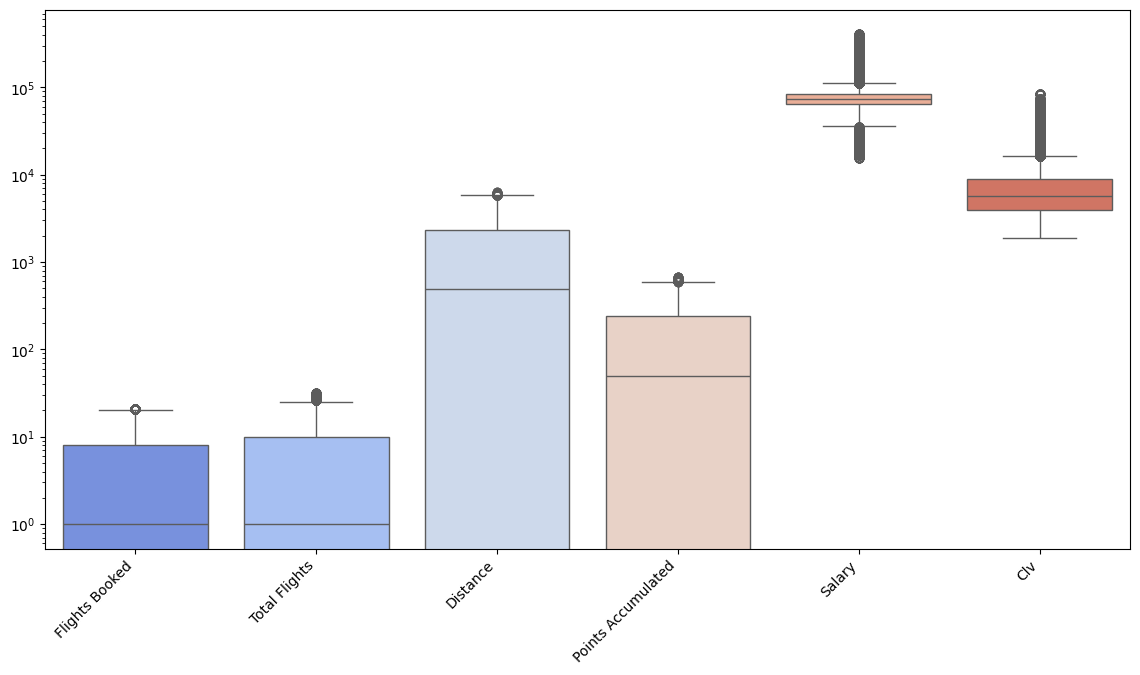

In [714]:
# Visual Outlier Audit

# Defining relatable business columns for visualization
viz_cols = ['flights_booked', 'total_flights', 'distance', 'points_accumulated', 'salary', 'clv']
viz_data = df_merged[viz_cols]

# Creating readable labels (Title Case with spaces)
clean_labels = [col.replace('_', ' ').title() for col in viz_cols]

plt.figure(figsize=(14, 7))
ax = sns.boxplot(data=viz_data, palette="coolwarm", showfliers=True)

# Formatting X-axis labels
ax.set_xticklabels(clean_labels, rotation=45, ha='right')

# Formatting Y-axis to handle log scale without scientific notation
plt.yscale('log')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.get_major_formatter().set_scientific(False)
ax.yaxis.get_major_formatter().set_useOffset(False)

plt.title("Dispersion and Outlier Identification in Key Metrics", fontsize=14, pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Linear Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Numerical Variables")
plt.show()

#### 2.2 Categorical Variables Analysis

In [711]:
# Obtaining detailed information for all numerical columns (object, bool and datetime)
categoric_data = df_merged.select_dtypes(include=["object", "bool", "period[M]"])

categoric_summary = pd.DataFrame({
    'Data Type': categoric_data.dtypes,
    'Total Rows': [len(df_merged)] * len(categoric_data.columns),
    'Data Present': categoric_data.count(),
    'Null Data': categoric_data.isnull().sum(),
    'Null Percentage (%)': (categoric_data.isnull().sum() / len(df_merged)) * 100
}).round(2)

print("--- Detailed Summary of All Categorical & Non-Numeric Columns ---")
display(categoric_summary)

--- Detailed Summary of All Categorical & Non-Numeric Columns ---


,Data Type,Total Rows,Data Present,Null Data,Null Percentage (%)
flight_date,period[M],405624,405624,0,0.00
country,object,405624,405624,0,0.00
province,object,405624,405624,0,0.00
city,object,405624,405624,0,0.00
postal_code,object,405624,405624,0,0.00
gender,object,405624,405624,0,0.00
education,object,405624,405624,0,0.00
marital_status,object,405624,405624,0,0.00
loyalty_card,object,405624,405624,0,0.00
enrollment_type,object,405624,405624,0,0.00
